<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Bodie%2C%20Z.%20(1995).%20On%20the%20risk%20of%20stocks%20in%20the%20long%20run/On_the_Risk_of_Stocks_in_the_Long_Run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

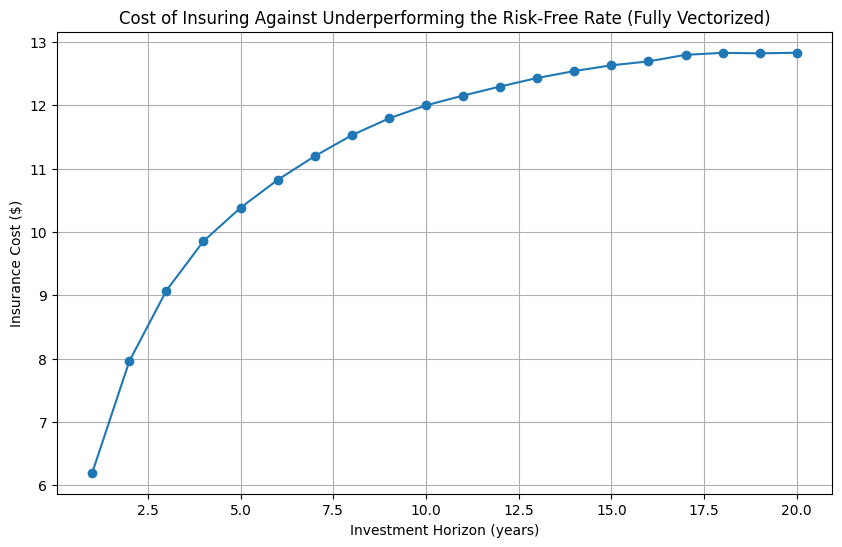

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
S0 = 100
mu = 0.07
sigma = 0.20
r = 0.03
#If T_max is too large like 30 it will crash the system
T_max = 20
dt = 1/252
simulations = 50000



# -----------------------------
# Simulate max-horizon paths once
# -----------------------------
N_max = int(T_max / dt)
Z = np.random.standard_normal((simulations, N_max))
increments = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
increments = np.hstack((np.zeros((simulations,1)), increments))
paths = S0 * np.exp(np.cumsum(increments, axis=1))

# -----------------------------
# Select final prices at each year horizon
# -----------------------------
year_indices = (np.arange(1, T_max+1) / dt).astype(int)
S_T_matrix = paths[:, year_indices]  # shape: (simulations, T_max)

# -----------------------------
# Compute insurance costs in batch
# -----------------------------
horizons = np.arange(1, T_max+1)
K = S0 * np.exp(r * horizons)           # strikes for each horizon
payoff = np.maximum(K - S_T_matrix, 0) # shape: (simulations, T_max)
discounted_payoff = payoff * np.exp(-r * horizons)  # discount each horizon
insurance_costs = discounted_payoff.mean(axis=0)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(horizons, insurance_costs, marker='o')
plt.title("Cost of Insuring Against Underperforming the Risk-Free Rate (Fully Vectorized)")
plt.xlabel("Investment Horizon (years)")
plt.ylabel("Insurance Cost ($)")
plt.grid(True)
plt.show()

This code simulates the cost of insuring a stock portfolio against underperforming the risk-free rate over different investment horizons using Monte Carlo methods. Instead of simulating each horizon separately, it generates daily stock paths for the maximum horizon and then extracts the final stock prices for each year. For each horizon, it computes the expected payoff of a put option that would protect the portfolio from falling below the risk-free growth, discounting the payoff to present value. By calculating all horizons at once, the code efficiently shows how the cost of insurance rises with the length of the investment period, illustrating that holding stocks longer does not eliminate risk and may even increase potential downside exposure.

The simulation shows that the cost of insuring a stock portfolio against underperforming the risk-free rate **increases with the investment horizon**. Even though the expected average return of stocks remains positive over time, the **distribution of possible outcomes widens**, meaning the chance of significant underperformance grows. This demonstrates Bodie’s key insight: **longer holding periods do not eliminate risk and can actually make downside protection more expensive**.
